In [56]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [57]:
K_REFINED = 1 # None = all refinements; set e.g. 1 to truncate Bayesian after k-th refinement

In [58]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

def load_run(run_dir):
    """Load results.json if present, else checkpoint.json. Returns flat dict."""
    results_path = os.path.join(run_dir, 'results.json')
    ckpt_path = os.path.join(run_dir, 'checkpoint.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            raw = json.load(f)
        s = raw['optimization_settings']
        method_name = list(raw['methods'].keys())[0]
        d = raw['methods'][method_name]
        d['optimization_settings'] = s
        d['method'] = method_name
        d['source'] = 'results'
        return d
    elif os.path.exists(ckpt_path):
        with open(ckpt_path) as f:
            d = json.load(f)
        d['source'] = 'checkpoint'
        return d
    return None

def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

0 runs found


In [59]:
def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for date in sorted(os.listdir(sweep_dir)):
            date_dir = os.path.join(sweep_dir, date)
            if not os.path.isdir(date_dir):
                continue
            for config in sorted(os.listdir(date_dir)):
                config_dir = os.path.join(date_dir, config)
                if not os.path.isdir(config_dir):
                    continue
                for run in sorted(os.listdir(config_dir)):
                    run_dir = os.path.join(config_dir, run)
                    if not os.path.isdir(run_dir):
                        continue
                    d = load_run(run_dir)
                    if d is None:
                        continue
                    s = d.get('optimization_settings', {})
                    runs.append({
                        'sweep': sweep,
                        'date': date,
                        'config': config,
                        'run': run,
                        'run_dir': run_dir,
                        'source': d['source'],
                        'method': d.get('method', '?'),
                        'weight_fb': s.get('weight_fb', float('nan')),
                        'alpha': s.get('alpha', float('nan')),
                        'num_coils': s.get('num_coils', '?'),
                        'n_evals': d.get('n_evals', float('nan')),
                        'best_cost': d.get('best_cost', float('nan')),
                        'best_flux_err': d.get('best_flux_err', float('nan')),
                        'best_fb_cost': d.get('best_fb_cost', float('nan')),
                        'fb_failures': d.get('fb_failures', float('nan')),
                        'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                        'stopping': d.get('stopping', '?'),
                        'data': d,
                    })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['date']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

16 runs found
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-01  best=9.4196e-01  evals=574  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-02  best=6.4825e-01  evals=1477  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-03  best=9.1763e-01  evals=721  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-04  best=9.1640e-01  evals=1015  stop=all refinements completed
  convergence_w5_lbfgs/04_18/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.8948e-01  evals=1777  stop=exceeded wall time
  convergence_w5_lbfgs/04_18/alpha:0.7

In [60]:
def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for date in sorted(os.listdir(sweep_dir)):
            if date.startswith('test'):
                continue
            date_dir = os.path.join(sweep_dir, date)
            if not os.path.isdir(date_dir):
                continue
            for config in sorted(os.listdir(date_dir)):
                config_dir = os.path.join(date_dir, config)
                if not os.path.isdir(config_dir):
                    continue
                for run in sorted(os.listdir(config_dir)):
                    run_dir = os.path.join(config_dir, run)
                    if not os.path.isdir(run_dir):
                        continue
                    d = load_run(run_dir)
                    if d is None:
                        continue
                    s = d.get('optimization_settings', {})
                    runs.append({
                        'sweep': sweep,
                        'date': date,
                        'config': config,
                        'run': run,
                        'run_dir': run_dir,
                        'source': d['source'],
                        'method': d.get('method', '?'),
                        'weight_fb': s.get('weight_fb', float('nan')),
                        'alpha': s.get('alpha', float('nan')),
                        'num_coils': s.get('num_coils', '?'),
                        'n_evals': d.get('n_evals', float('nan')),
                        'best_cost': d.get('best_cost', float('nan')),
                        'best_flux_err': d.get('best_flux_err', float('nan')),
                        'best_fb_cost': d.get('best_fb_cost', float('nan')),
                        'fb_failures': d.get('fb_failures', float('nan')),
                        'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                        'stopping': d.get('stopping', '?'),
                        'data': d,
                    })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['date']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

8 runs found
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-01  best=9.4196e-01  evals=574  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-02  best=6.4825e-01  evals=1477  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-03  best=9.1763e-01  evals=721  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-04  best=9.1640e-01  evals=1015  stop=all refinements completed
  convergence_w5_lbfgs/04_18/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Multi-start L-BFGS  weight_fb=1e-01  best=1.8948e-01  evals=1777  stop=exceeded wall time
  convergence_w5_lbfgs/04_18/alpha:0.75

In [61]:
rows = []
for r in runs:
    d = r['data']
    alpha = d.get('optimization_settings', {}).get('alpha', 0.75)

    total = np.array(d['cost_history'], dtype=float)
    flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
    fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', 0)
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]

    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'source': r['source'],
        'alpha': alpha,
        'best_cost_stored': float(np.nanmin(total)),
        'best_flux_err': float(np.nanmin(flux)),
        'best_fb_cost': float(np.nanmin(fb)),
        'init_fixed': d.get('initial_fixed_cost') or float('nan'),
        'init_fb': d.get('initial_fb_cost') or float('nan'),
        'fb_failures': r['fb_failures'],
        'n_evals': len(total),
        'elapsed_h': r['elapsed'] / 3600,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

shared_norm_fixed = df['init_fixed'].max()
shared_norm_fb = df['init_fb'].max()
print(f"shared_norm_fixed={shared_norm_fixed:.4e}  shared_norm_fb={shared_norm_fb:.4e}")

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / shared_norm_fixed +
    df['alpha'] * df['best_fb_cost'] / shared_norm_fb
)

df = df.sort_values(['sweep', 'weight_fb'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

shared_norm_fixed=2.0760e-01  shared_norm_fb=9.5215e+00


,sweep,method,weight_fb,num_coils,source,alpha,best_cost_stored,best_flux_err,best_fb_cost,init_fixed,init_fb,fb_failures,n_evals,elapsed_h,stopping,best_cost_shared
3,convergence_w5_bayesian,Bayesian,1.0000e-04,3,results,7.5000e-01,1.0000e+00,9.9392e-03,6.0453e-01,1.3629e-02,7.2958e-01,198,294,1.4248e+01,all refinements completed,5.9588e-02
2,convergence_w5_bayesian,Bayesian,1.0000e-03,3,results,7.5000e-01,1.0000e+00,1.2071e-02,6.0504e-01,1.3629e-02,7.2938e-01,3,238,9.9724e+00,all refinements completed,6.2195e-02
1,convergence_w5_bayesian,Bayesian,1.0000e-02,3,results,7.5000e-01,6.4825e-01,5.8378e-03,5.2134e-01,1.3629e-02,7.2253e-01,65,77,1.9501e+01,all refinements completed,4.8096e-02
0,convergence_w5_bayesian,Bayesian,1.0000e-01,3,results,7.5000e-01,9.4196e-01,9.1080e-03,1.8038e+00,1.3629e-02,2.0070e+00,3,168,8.5453e+00,all refinements completed,1.5305e-01
7,convergence_w5_lbfgs,Multi-start L-BFGS,1.0000e-04,3,results,7.5000e-01,1.0522e-01,9.2559e-03,1.0058e+00,2.0760e-01,9.5215e+00,21,1717,2.4012e+01,exceeded wall time,9.0370e-02
6,convergence_w5_lbfgs,Multi-start L-BFGS,1.0000e-03,3,results,7.5000e-01,1.3117e-01,9.2299e-03,1.3483e+00,2.0760e-01,9.4351e+00,43,1771,2.4007e+01,exceeded wall time,1.1732e-01
5,convergence_w5_lbfgs,Multi-start L-BFGS,1.0000e-02,3,results,7.5000e-01,1.1963e-01,9.2559e-03,1.1945e+00,2.0760e-01,8.2582e+00,21,1739,2.4005e+01,exceeded wall time,1.0523e-01
4,convergence_w5_lbfgs,Multi-start L-BFGS,1.0000e-01,3,results,7.5000e-01,1.8948e-01,1.1266e-02,2.1653e+00,2.0760e-01,9.2317e+00,62,1777,2.4001e+01,exceeded wall time,1.8412e-01


In [62]:
corrected_elapsed = []
for r in runs:
    d = r['data']
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        t_bay = d.get('time_bayesian_phase', float('nan'))
        ref_times = d.get('refinement_times', [])
        elapsed = t_bay + sum(ref_times[:min(K_REFINED, len(ref_times))])
    else:
        elapsed = r['elapsed']
    corrected_elapsed.append(elapsed / 3600)

df['elapsed_h'] = corrected_elapsed

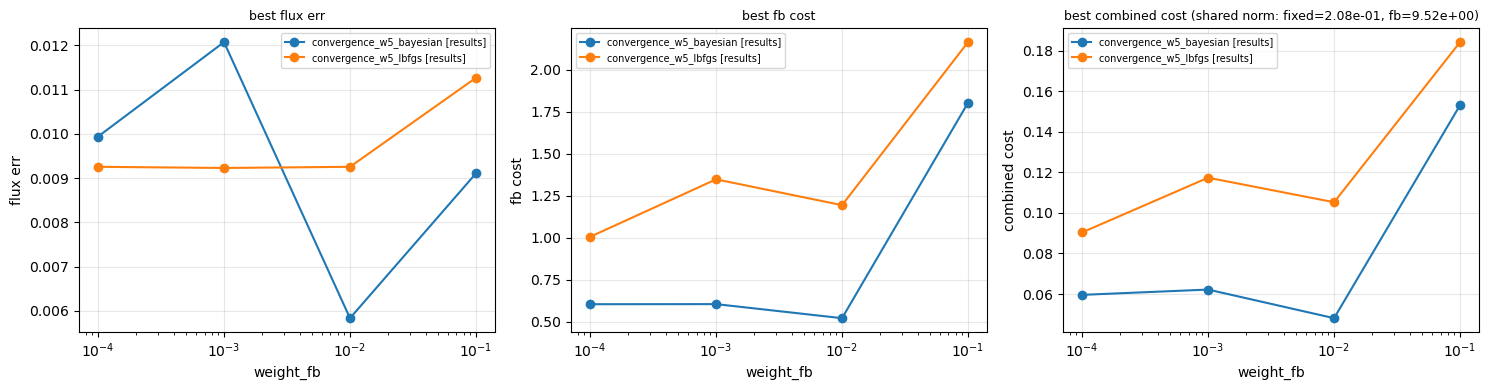

In [63]:
sweeps = df['sweep'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for sweep in sweeps:
    sub = df[df['sweep'] == sweep].sort_values('weight_fb')
    label = f"{sweep} [{sub['source'].iloc[0]}]"
    axes[0].plot(sub['weight_fb'], sub['best_flux_err'], marker='o', label=label)
    axes[1].plot(sub['weight_fb'], sub['best_fb_cost'], marker='o', label=label)
    axes[2].plot(sub['weight_fb'], sub['best_cost_shared'], marker='o', label=label)

for ax, title, ylabel in zip(
    axes,
    ['best flux err', 'best fb cost', f'best combined cost (shared norm: fixed={shared_norm_fixed:.2e}, fb={shared_norm_fb:.2e})'],
    ['flux err', 'fb cost', 'combined cost']
):
    ax.set_xscale('log')
    ax.set_xlabel('weight_fb')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

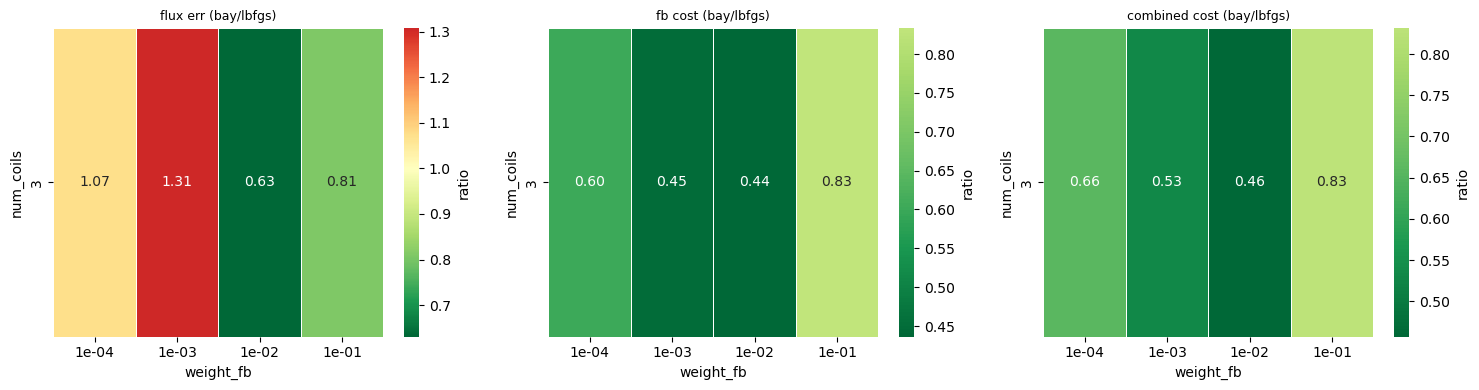

In [64]:
import seaborn as sns

bay = df[df['sweep'].str.contains('bayesian')].set_index(['num_coils', 'weight_fb'])
lbf = df[~df['sweep'].str.contains('bayesian')].set_index(['num_coils', 'weight_fb'])

metrics = ['best_flux_err', 'best_fb_cost', 'best_cost_shared']
titles = ['flux err (bay/lbfgs)', 'fb cost (bay/lbfgs)', 'combined cost (bay/lbfgs)']
ratio = bay[metrics] / lbf[metrics]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, metrics, titles):
    pivot = ratio[[col]].reset_index().pivot(index='num_coils', columns='weight_fb', values=col)
    pivot.columns = [f'{w:.0e}' for w in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'ratio'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('num_coils')

plt.tight_layout()
plt.show()

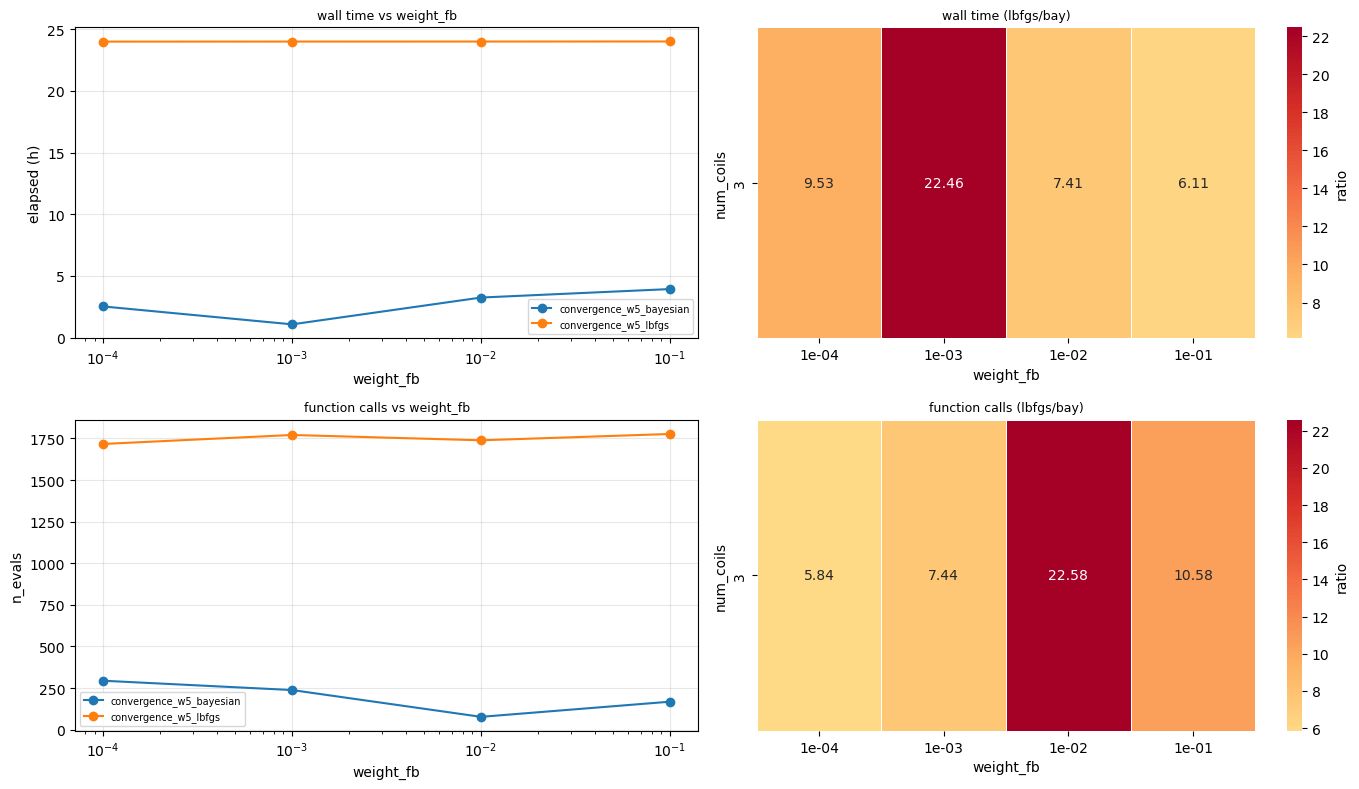

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for sweep in df['sweep'].unique():
    sub = df[df['sweep'] == sweep].sort_values('weight_fb')
    axes[0][0].plot(sub['weight_fb'], sub['elapsed_h'], marker='o', label=sweep)
    axes[1][0].plot(sub['weight_fb'], sub['n_evals'], marker='o', label=sweep)

for ax, ylabel, title in [
    (axes[0][0], 'elapsed (h)', 'wall time vs weight_fb'),
    (axes[1][0], 'n_evals', 'function calls vs weight_fb'),
]:
    ax.set_xscale('log')
    ax.set_xlabel('weight_fb')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for ratio_data, ax, title in [
    (lbf[['elapsed_h']] / bay[['elapsed_h']], axes[0][1], 'wall time (lbfgs/bay)'),
    (lbf[['n_evals']] / bay[['n_evals']], axes[1][1], 'function calls (lbfgs/bay)'),
]:
    col = ratio_data.columns[0]
    pivot = ratio_data.reset_index().pivot(index='num_coils', columns='weight_fb', values=col)
    pivot.columns = [f'{w:.0e}' for w in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'ratio'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('num_coils')

plt.tight_layout()
plt.show()

In [66]:
lbfgs_runs = [r for r in runs if r['method'] != 'Bayesian']

all_drops = {w: [] for w in sorted(set(r['weight_fb'] for r in lbfgs_runs))}
summary_rows = []

for r in lbfgs_runs:
    d = r['data']
    cost = np.array(d['cost_history'], dtype=float)
    boundaries = [0] + list(d['start_boundaries'])

    for i in range(len(boundaries) - 1):
        seg = cost[boundaries[i]:boundaries[i+1]]
        if len(seg) < 2:
            continue
        drops = -np.diff(seg)
        summary_rows.append({
            'weight_fb': r['weight_fb'],
            'start': i + 1,
            'n_evals': len(seg),
            'start_cost': seg[0],
            'best_drop': float(seg[0] - np.nanmin(seg)),
            'median_step_drop': float(np.median(np.abs(drops))),
            'p90_step_drop': float(np.percentile(np.abs(drops), 90)),
            'pct_improving': float(np.mean(drops > 0) * 100),
        })
        all_drops[r['weight_fb']].extend(drops.tolist())

ds = pd.DataFrame(summary_rows)
pd.set_option('display.float_format', '{:.3e}'.format)
print(ds.to_string(index=False))


 weight_fb  start  n_evals  start_cost  best_drop  median_step_drop  p90_step_drop  pct_improving
 1.000e-01      1      462   1.004e+00  2.192e-01         3.034e-07      4.423e-06      5.076e+01
 1.000e-01      2      147   1.464e+00  2.012e-09         3.808e-09      8.725e-08      5.342e+01
 1.000e-01      3      532   8.124e+04  8.124e+04         5.443e-09      1.515e-07      5.066e+01
 1.000e-01      4      350   3.540e-01  7.758e-02         2.209e-08      1.657e-03      5.100e+01
 1.000e-01      5      147   1.087e+00  8.972e-01         1.243e-08      2.413e-03      5.274e+01
 1.000e-02      1      238   1.004e+00  4.975e-01         1.850e-08      1.525e-05      5.612e+01
 1.000e-02      2      371   8.520e-01  1.531e-01         5.900e-09      2.969e-06      5.297e+01
 1.000e-02      3      427   9.082e+04  9.082e+04         4.259e-06      1.680e-05      4.953e+01
 1.000e-02      4      438   4.417e-01  2.496e-01         8.027e-08      2.872e-04      5.561e+01
 1.000e-02      5   

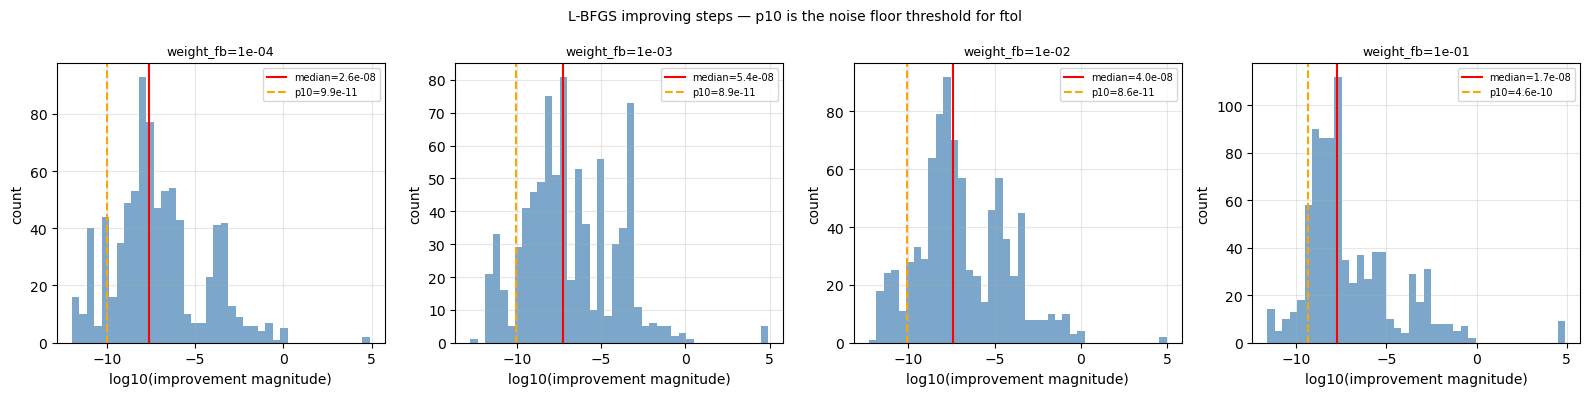

In [67]:
fig, axes = plt.subplots(1, len(all_drops), figsize=(4 * len(all_drops), 4), sharey=False)
for ax, (w, drops) in zip(axes, sorted(all_drops.items())):
    drops = np.array(drops)
    improving = drops[drops > 0]
    if len(improving):
        ax.hist(np.log10(improving), bins=40, color='steelblue', alpha=0.7)
        ax.axvline(np.log10(np.median(improving)), color='red', lw=1.5, label=f'median={np.median(improving):.1e}')
        ax.axvline(np.log10(np.percentile(improving, 10)), color='orange', lw=1.5, ls='--', label=f'p10={np.percentile(improving, 10):.1e}')
    ax.set_title(f'weight_fb={w:.0e}', fontsize=9)
    ax.set_xlabel('log10(improvement magnitude)')
    ax.set_ylabel('count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('L-BFGS improving steps — p10 is the noise floor threshold for ftol', fontsize=10)
plt.tight_layout()
plt.show()

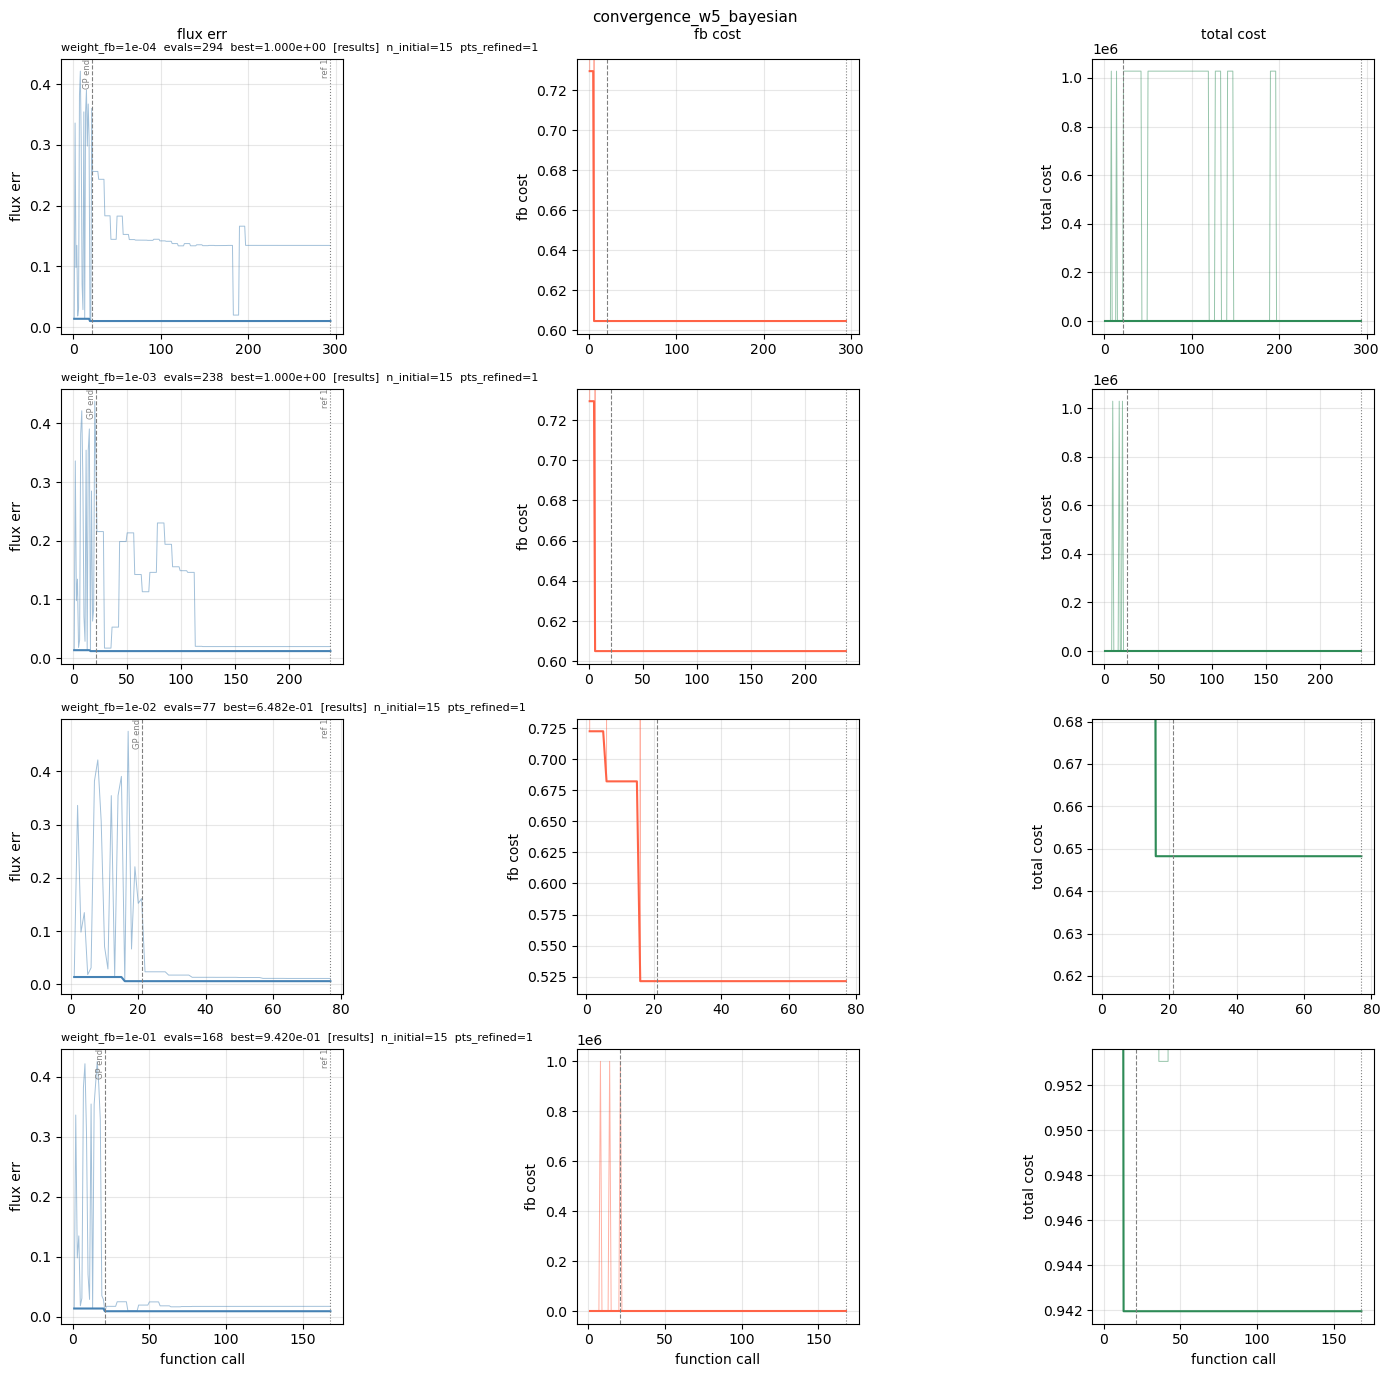

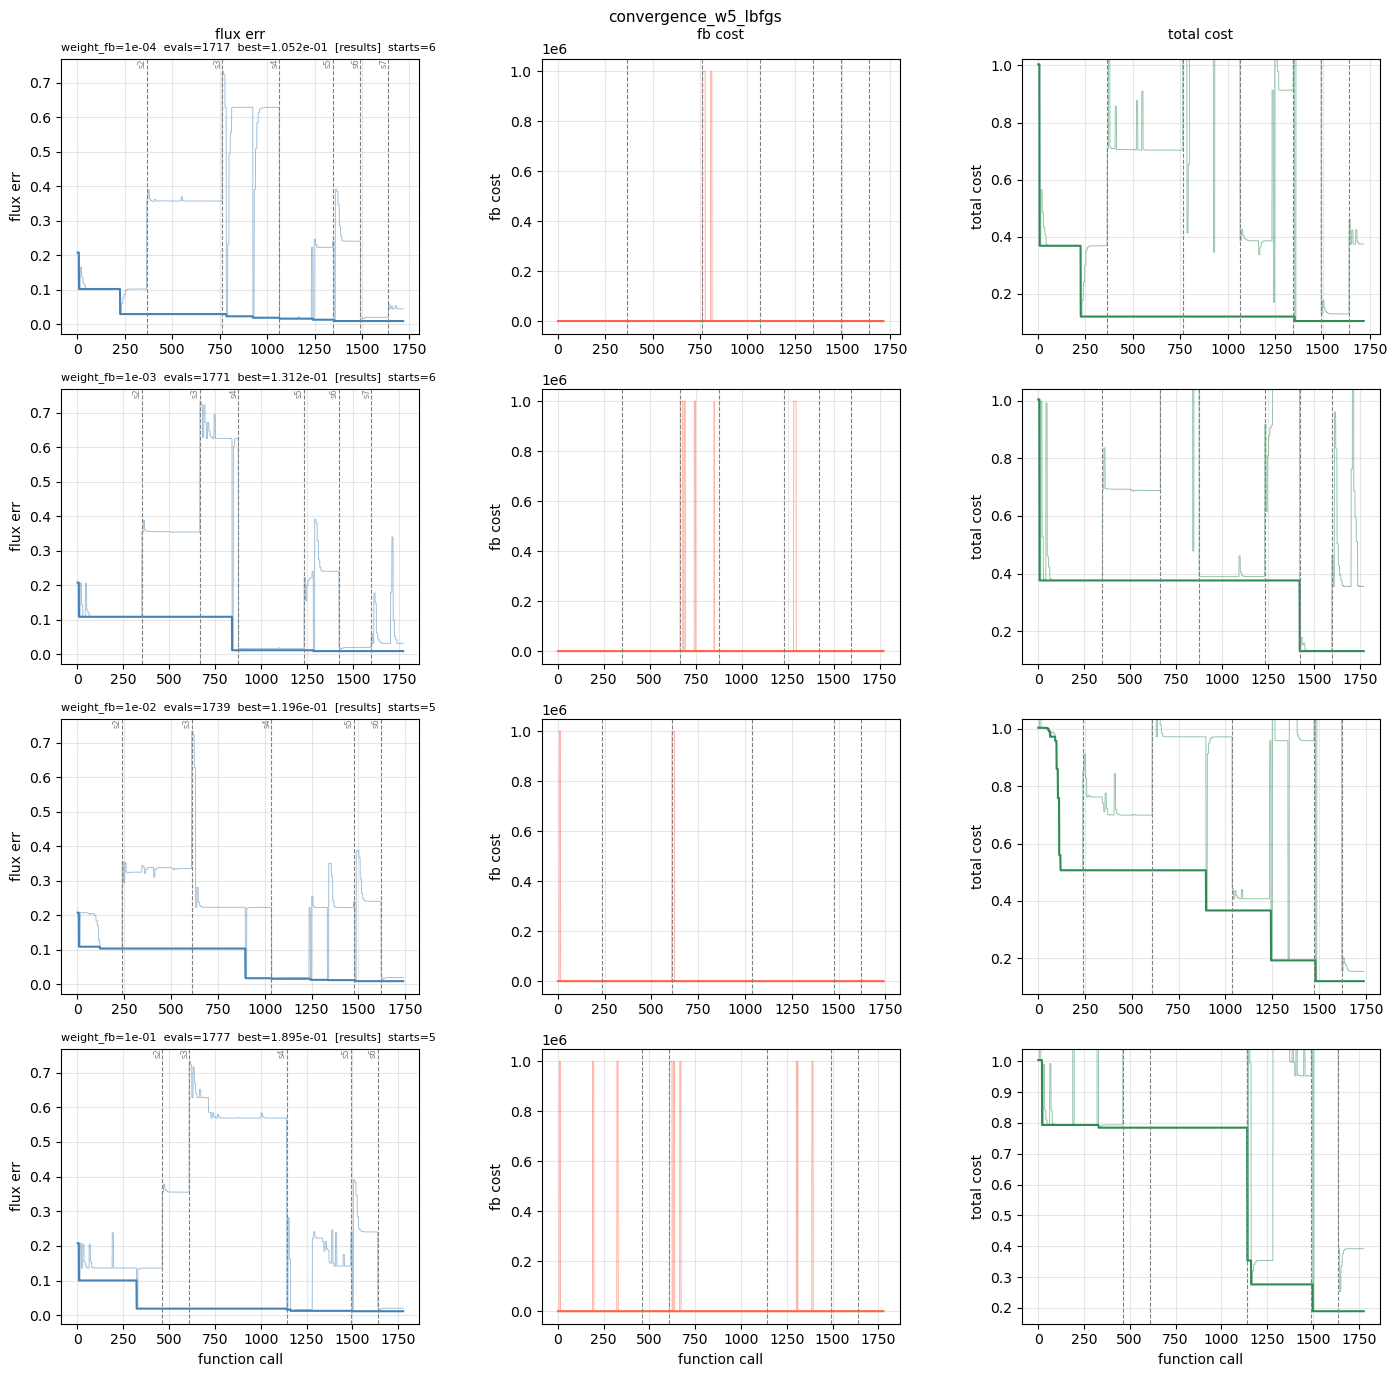

In [68]:
# --- filter ---
SHOW_SWEEPS = None   # None = all, or e.g. ['convergence_w5']
SHOW_WEIGHTS = None  # None = all, or e.g. [1e-2, 1e-4]
SHOW_COILS = None    # None = all, or e.g. [3, 4]
CLIP = 1           # values >= this are plotted but ignored for ylim
# --------------

filtered = [
    r for r in runs
    if (SHOW_SWEEPS is None or r['sweep'] in SHOW_SWEEPS)
    and (SHOW_WEIGHTS is None or any(abs(r['weight_fb'] - w) < 1e-12 for w in SHOW_WEIGHTS))
    and (SHOW_COILS is None or r['num_coils'] in SHOW_COILS)
]

COL_LABELS = ['flux err', 'fb cost', 'total cost']

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = [r for r in filtered if r['sweep'] == sweep]
    n = len(sweep_runs)
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n), sharex=False, squeeze=False)
    fig.suptitle(sweep, fontsize=11)

    for col, label in enumerate(COL_LABELS):
        axes[0][col].set_title(label, fontsize=10, pad=14)

    for row, r in enumerate(sorted(sweep_runs, key=lambda x: x['weight_fb'])):
        d = r['data']
        total = np.array(d['cost_history'], dtype=float)
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []  # (label, x, linestyle)

        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cumulative = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cumulative += re
                phase_lines.append((f'ref {i+1}', cumulative, ':'))
            pts_label = k if K_REFINED is not None else d.get('pts_refined', '?')
            extra = f"  n_initial={d.get('n_initial','?')}  pts_refined={pts_label}"
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))
            extra = f"  starts={d.get('starts_completed','?')}"

        evals = np.arange(1, len(total) + 1)
        run_title = f"weight_fb={r['weight_fb']:.0e}  evals={len(total)}  best={np.nanmin(total):.3e}  [{r['source']}]{extra}"

        for ax, y, color, ylabel in zip(
            axes[row],
            [flux, fb, total],
            ['steelblue', 'tomato', 'seagreen'],
            COL_LABELS,
        ):
            ax.plot(evals, y, lw=0.7, alpha=0.5, color=color)
            running_best = np.minimum.accumulate(np.where(np.isnan(y), np.inf, y))
            running_best[running_best == np.inf] = np.nan
            ax.plot(evals, running_best, lw=1.5, color=color)
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if row == len(sweep_runs) - 1:
                ax.set_xlabel('function call')

            finite = y[np.isfinite(y) & (y < CLIP)]
            if len(finite):
                pad = (finite.max() - finite.min()) * 0.05 or finite.min() * 0.05
                ax.set_ylim(finite.min() - pad, finite.max() + pad)

            for lbl, x, ls in phase_lines:
                ax.axvline(x, color='gray', lw=0.8, ls=ls)
                if ax is axes[row][0]:
                    ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right',
                            va='top', rotation=90, color='gray')

        axes[row][0].annotate(run_title, xy=(0, 1), xycoords='axes fraction',
                              xytext=(0, 4), textcoords='offset points',
                              fontsize=8, va='bottom')

    plt.tight_layout()
    plt.show()